In [1]:
import argparse
import os
import time
import glog, json

import torch
import torch.multiprocessing as mp
from transformers import AutoModelForCausalLM, AutoTokenizer, LlavaForConditionalGeneration
from transformers.modeling_attn_mask_utils import \
    _prepare_4d_causal_attention_mask

from operator import attrgetter

import sys
notebook_dir = os.path.dirname(os.path.abspath("__file__"))
project_root = os.path.abspath(os.path.join(notebook_dir, ".."))

# std = 0.012528747320175171
if project_root not in sys.path:
    sys.path.append(project_root)
# sys.path.append(os.path.dirname(os.path.abspath(os.path.dirname(__file__))))

from NWC.models import get_model

class Config:
    def __init__(self, **entries):
        self.__dict__.update(entries)
        

def load_comp_model(comp_model_path):
    config = os.path.join(os.path.dirname(comp_model_path), 'config.json')
    with open(config, 'r', encoding='utf-8') as file:
        config = json.load(file)
    config = Config(**config)
    
    shift, scale = torch.empty(()), torch.empty(())
    if config.architecture == 'nwc_ql' and not hasattr(config, "Q"):
        config.Q = 4
    if not hasattr(config, "no_layernorm"):
        config.no_layernorm = False
    

    comp_model = get_model(config.architecture, config, scale=scale, shift=shift)
    comp_model.config = config
    ckpt = torch.load(comp_model_path, weights_only=False)
    try:
        scale = ckpt["state_dict"]["scale"]
        shift = ckpt["state_dict"]["shift"]
        print('Use train scale and shift')
        print('shift: ', shift, ' scale:', scale)
    except:
        scale, shift  = torch.zeros(1), torch.zeros(1)


    comp_model.load_state_dict(ckpt["state_dict"], strict = False)
    # comp_model.scale = scale
    # comp_model.shift = shift
    try: ## scale_cond
        comp_model.scale.copy_(scale)
        comp_model.shift.copy_(shift)
    except:
        pass
    comp_model.eval()
    comp_model.update()

    return comp_model

W1125 10:12:34.195044 96672 warnings.py:109] /opt/conda/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm

W1125 10:12:34.853321 96672 warnings.py:109] /opt/conda/lib/python3.10/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: '/opt/conda/lib/python3.10/site-packages/torchvision/image.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(

I1125 10:12:36.156400 96672 utils.py:148] Note: detected 128 virtual cores but NumExpr set to maximum of 64, check "NUMEXPR_MAX_THREADS" environment variable.
I1125 10:12:

In [3]:
path = "/home/jgryu/workspace/weight_compression/NWC/checkpoint/nwc_ql/block_seq_ql_random_scaler_meta-llama--Meta-Llama-3-8B__col_1024_gaussian_padding.pt/M16/lmbda300_rdloss_ql_size16_encdim512_M16_Q4_R0_m0_batch_size2048_total_iter200000_lr0.0001_seed100/best_loss_model_loss_5.32101_bpp_5.72603_MSE_0.00289_total_iter_95000.pth.tar"
nwc = load_comp_model(path)

In [2]:
base_model = '/home/jgryu/workspace/weight_compression/Wparam_dataset/hf_model/meta-llama--Meta-Llama-3-8B'
model = AutoModelForCausalLM.from_pretrained(base_model,
                                                torch_dtype='auto',
                                                low_cpu_mem_usage=True,
                                                local_files_only=True,)


Loading checkpoint shards: 100%|██████████| 7/7 [00:00<00:00,  7.82it/s]


In [4]:
import math

def comp_W(W, H, model,**kwargs):    
    bs = min(W.shape[1], 4096*4096 // W.shape[0])
    (m, n) = W.shape
    glog.info(f'{W.shape}')
    W_hat = torch.zeros_like(W)
    num_pixels = 0
    bpp_loss_sum = 0
    bpp_sum = 0
    codes = []
    
    # row_norm = kwargs.get('row_norm', None)  # (m, 1)
    # col_norm = kwargs.get('col_norm', None)  # (1, n)

    scale_cond = kwargs.get('scale_cond', None)  # (1, n)
    
    qlevel = kwargs.get('qlevel', None)
    qlevel = qlevel.reshape(W.shape[1], ) if qlevel is not None else None
    
    y_in_list = kwargs.get('y_in_list', None)
    
    
    for i,e in enumerate(range(n, 0, -bs)):
        s = max(0, e - bs)

        w = W[:, s:e]        
        
        ql = qlevel[s:e] if qlevel is not None else None
        sc = scale_cond[:, s:e] if scale_cond is not None else None
 
        x_hat, n_pixels, bpp_loss_, out, out_enc, nbits = model_foward_one_batch(w.clone(), model, ql = ql, sc = sc)

        codes.append(out_enc)
        bpp_sum += nbits
        W_hat[:, s:e] = x_hat
        num_pixels += n_pixels
        bpp_loss_sum += bpp_loss_
    
    return {'hatWr': W_hat,
            'bpp_loss_sum': bpp_loss_sum.item(),
            'bpp_loss': bpp_loss_sum.item() / num_pixels,
            'num_pixels': num_pixels,
            'bpp_sum': bpp_sum,
            'bpp': bpp_sum / num_pixels,
            'codes': codes,
            'bpp_loss_for_train': bpp_loss_sum / num_pixels,
            }   
    
def model_foward_one_batch(w, model, **kwargs):
    y_in = kwargs.get('y_in', None)
    mode = kwargs.get('mode', 'init')
    ql = kwargs.get('ql', None)  # (n, )
    (m, n) = w.shape if w is not None else kwargs.get('shape', None)
    
    blks = model.input_size
    # assert (m if args.direction == 'col' else n) % blks == 0
    original_m, original_n = m, n
    pad_len = 0    
    # if args.direction == 'col':
    if 'col' == 'col':
        # Col 방향일 때는 m(행)이 blks의 배수여야 함
        if m % blks != 0:
            pad_len = blks - (m % blks)
            # w shape: (m, n) -> pad bottom rows: (last_dim_left, last_dim_right, 2nd_last_left, 2nd_last_right)
            # (0, 0, 0, pad_len)
            if w is not None:
                w = F.pad(w, (0, 0, 0, pad_len))
            m = m + pad_len  # m 업데이트
    else:
        # Row 방향일 때는 n(열)이 blks의 배수여야 함
        if n % blks != 0:
            pad_len = blks - (n % blks)
            # w shape: (m, n) -> pad right cols
            if w is not None:
                w = F.pad(w, (0, pad_len))
            n = n + pad_len  # n 업데이트
    
    
    sc = kwargs.get('sc', None)  # (1, n)
    sc = sc.repeat(m, 1) if sc is not None else None #(m, n)
    
    # if ql is not None:
    #     ql = ql.reshape(1, n).expand(m//blks, n)
    # elif args.ql_search_value is not None:
    ql = torch.full((m//blks, n), 1, dtype=torch.int32, device=w.device)
    
    transpose = True
    w = w.T if (w is not None and transpose) else w
    ql = ql.T if (ql is not None and transpose) else ql
    # qm = qm.T if (qm is not None and transpose) else qm
    sc = sc.T if sc is not None and transpose else sc
    
    data = {}
    if w is not None:
        w = w.reshape(1, -1, blks)
    data['weight_block'] = w
    # assert torch.isnan(w).any() == False
    
    if ql is not None:
        data['q_level'] = ql.reshape(1, m*n//blks)
    # if qm is not None:
    #     data['qmap'] = qm.reshape(1, w.shape[1])
    if hasattr(model, 'pe') and model.pe:
        wtype_mapping = {'q': 0, 'k': 1, 'v': 2, 'o': 3, 'gate': 4, 'up': 5, 'down': 6}
        depth = args.layer_idx
        ltype = wtype_mapping[args.layer_name]
        data['depth'] = torch.full((1, 1), depth, dtype=torch.long).to(w.device)
        data['ltype'] = torch.full((1, 1), ltype, dtype=torch.long).to(w.device)
    if sc is not None:
        sc =  sc.reshape(1, -1, blks)       
        if hasattr(model, 'scale_cond') and model.scale_cond:
            assert torch.all(sc == sc[..., :1])
            sc = sc[..., 0] #(1,  m*n//blks)
            assert sc.shape == (1, m*n//blks)
        data['scale_cond'] = sc
        
    num_pixels = m*n
    bpp_loss_sum = torch.tensor(0)
    nbits = 0
    out_enc = None
    out = None
    
    q_embed = model.quality_embedding(data['q_level']) # (B, -1, encdim)
    
    
    w_hat = model.g_a(w, q_embed)
        
    if True:
        # 현재 w_hat은 (n, m) 형태 (padding 포함)
        w_hat = w_hat.reshape(n, m).transpose(0, 1).contiguous()
        # 복원된 w_hat은 (m, n). 여기서 m은 패딩된 크기.
        if pad_len > 0:
            w_hat = w_hat[:original_m, :]
    else:
        w_hat = w_hat.reshape(m, n)
        if pad_len > 0:
            w_hat = w_hat[:, :original_n]

    torch.cuda.empty_cache()
    
    return w_hat, num_pixels, bpp_loss_sum, out, out_enc, nbits

In [11]:
W  =  model.model.layers[0].self_attn.q_proj.weight
# W  =  model.model.layers[10].self_attn.q_proj.weight
torch.cuda.empty_cache()
deivce = torch.device('cuda:5')
W = W.to(deivce)
nwc.to(deivce)
out = comp_W(W, None, nwc)
W_hat = out['hatWr']

I1125 10:23:23.121604 96672 3626035636.py:6] torch.Size([4096, 4096])


OutOfMemoryError: CUDA out of memory. Tried to allocate 2.00 GiB. GPU 5 has a total capacity of 47.54 GiB of which 1.63 GiB is free. Process 2220307 has 4.36 GiB memory in use. Process 2494163 has 19.87 GiB memory in use. Process 2715164 has 21.66 GiB memory in use. Of the allocated memory 21.34 GiB is allocated by PyTorch, and 16.67 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

Tensor     | Kurtosis   | Max Sigma  | Outlier(>3σ)   
-------------------------------------------------------
W          | 16.91      | 30.00      | 2.00%
W_hat      | -0.00      | 2.70       | 0.00%
W_fft      | 0.39       | 7.35       | 0.63%
W_had      | 6.09       | 21.93      | 1.98%


I1125 10:14:50.205559 96672 category.py:224] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
I1125 10:15:22.726993 96672 category.py:224] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
W1125 10:15:34.696778 96672 warnings.py:109] /tmp/ipykernel_96672/1836777563.py:86: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(list(data_dict.keys()))



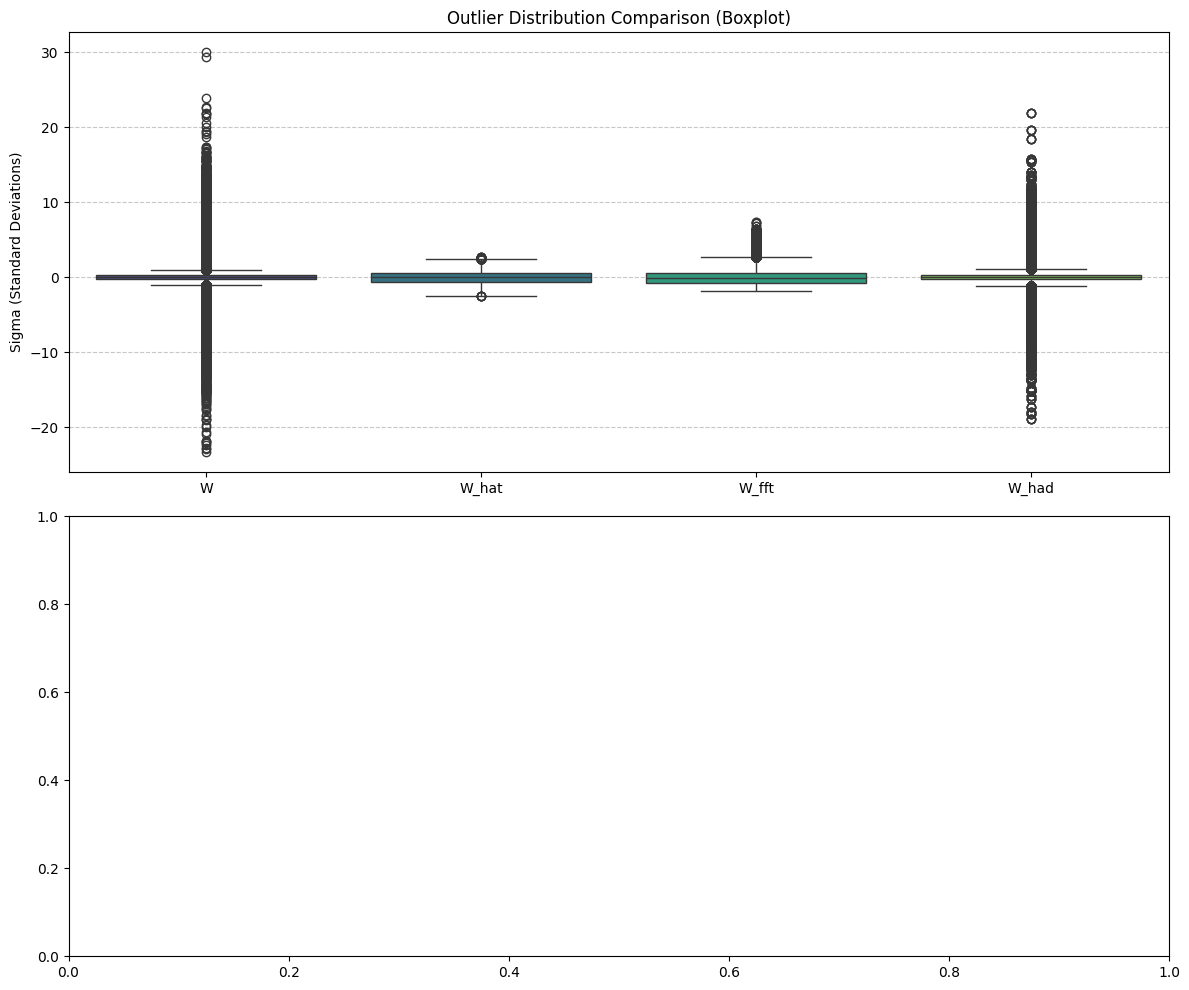

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kurtosis
from scipy.linalg import hadamard

# -------------------------------------------------------
# 1. 유틸리티 함수 (변환 및 정규화)
# -------------------------------------------------------

def to_numpy(tensor):
    if hasattr(tensor, 'detach'):
        return tensor.detach().cpu().numpy()
    return tensor

def normalize_zscore(data):
    """평균 0, 표준편차 1로 정규화 (Sigma 단위로 변환)"""
    eps = 1e-8
    return (data - np.mean(data)) / (np.std(data) + eps)

def apply_fft(mat):
    """2D FFT Magnitude 계산"""
    f_transform = np.fft.fft2(mat)
    return np.abs(np.fft.fftshift(f_transform))

def apply_hadamard(mat):
    """Walsh-Hadamard Transform (Zero-padding 적용)"""
    rows, cols = mat.shape
    max_dim = max(rows, cols)
    next_power_of_2 = 2**int(np.ceil(np.log2(max_dim)))
    
    # Padding
    padded = np.zeros((next_power_of_2, next_power_of_2))
    padded[:rows, :cols] = mat
    
    # H * W (행 변환을 통해 값을 섞음)
    H = hadamard(next_power_of_2)
    return H @ padded

# -------------------------------------------------------
# 2. 데이터 준비 (4가지 변수 생성)
# -------------------------------------------------------

# [중요] 사용자의 W, W_hat이 있다고 가정 (없으면 랜덤 생성)
# W = np.random.randn(128, 128) 
# W[0, 0] = 50 # 인위적 이상치 추가
# W_hat = W + np.random.normal(0, 0.5, (128, 128))

# 1) NumPy 변환
w_np = to_numpy(W)
w_hat_np = to_numpy(W_hat)

# 2) 변환 수행 (W_fft, W_had 생성)
w_fft_np = apply_fft(w_np)
w_had_np = apply_hadamard(w_np)

# 3) Flatten & Normalize (모두 1차원 배열 및 Z-Score로 변환)
data_dict = {
    "W": normalize_zscore(w_np.flatten()),
    "W_hat": normalize_zscore(w_hat_np.flatten()),
    "W_fft": normalize_zscore(w_fft_np.flatten()),
    "W_had": normalize_zscore(w_had_np.flatten())
}

# -------------------------------------------------------
# 3. 통계 및 시각화 (4개 동시 비교)
# -------------------------------------------------------

# (1) 통계 테이블 출력
print(f"{'Tensor':<10} | {'Kurtosis':<10} | {'Max Sigma':<10} | {'Outlier(>3σ)':<15}")
print("-" * 55)

stats_list = []
for name, data in data_dict.items():
    kurt = kurtosis(data)
    max_sigma = np.max(np.abs(data))
    outlier_pct = np.sum(np.abs(data) > 3) / len(data) * 100
    
    print(f"{name:<10} | {kurt:<10.2f} | {max_sigma:<10.2f} | {outlier_pct:.2f}%")

# (2) 시각화
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# A. Combined Boxplot (이상치 범위 비교)
sns.boxplot(data=list(data_dict.values()), ax=axes[0], palette="viridis", showfliers=True)
axes[0].set_xticklabels(list(data_dict.keys()))
axes[0].set_title("Outlier Distribution Comparison (Boxplot)")
axes[0].set_ylabel("Sigma (Standard Deviations)")
axes[0].grid(True, axis='y', linestyle='--', alpha=0.7)

# B. Combined Histogram (Log Scale - 꼬리 비교)
# colors = ['blue', 'red', 'green', 'purple']
# for i, (name, data) in enumerate(data_dict.items()):
#     sns.histplot(data, element="step", fill=False, stat="density", 
#                  label=name, color=colors[i], alpha=0.8, linewidth=1.5, ax=axes[1])

# axes[1].set_yscale('log') # 로그 스케일로 꼬리 부분 확대
# axes[1].set_title("Density Distribution Comparison (Log Scale)")
# axes[1].set_xlabel("Sigma (Z-Score)")
# axes[1].set_ylabel("Log Density")
# axes[1].legend()

plt.tight_layout()
plt.show()

Tensor     | Kurtosis   | Max Sigma  | Outlier(>3σ)   
-------------------------------------------------------
Original   | 20.48      | 43.57      | 1.94%
DCT        | 0.46       | 10.54      | 0.50%
Rand_Rot   | 5.42       | 16.77      | 1.86%
Rand_Had   | 5.44       | 16.66      | 1.86%
W_hat      | -0.00      | 2.70       | 0.00%


W1125 10:24:34.625389 96672 warnings.py:109] /tmp/ipykernel_96672/2995308957.py:85: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(



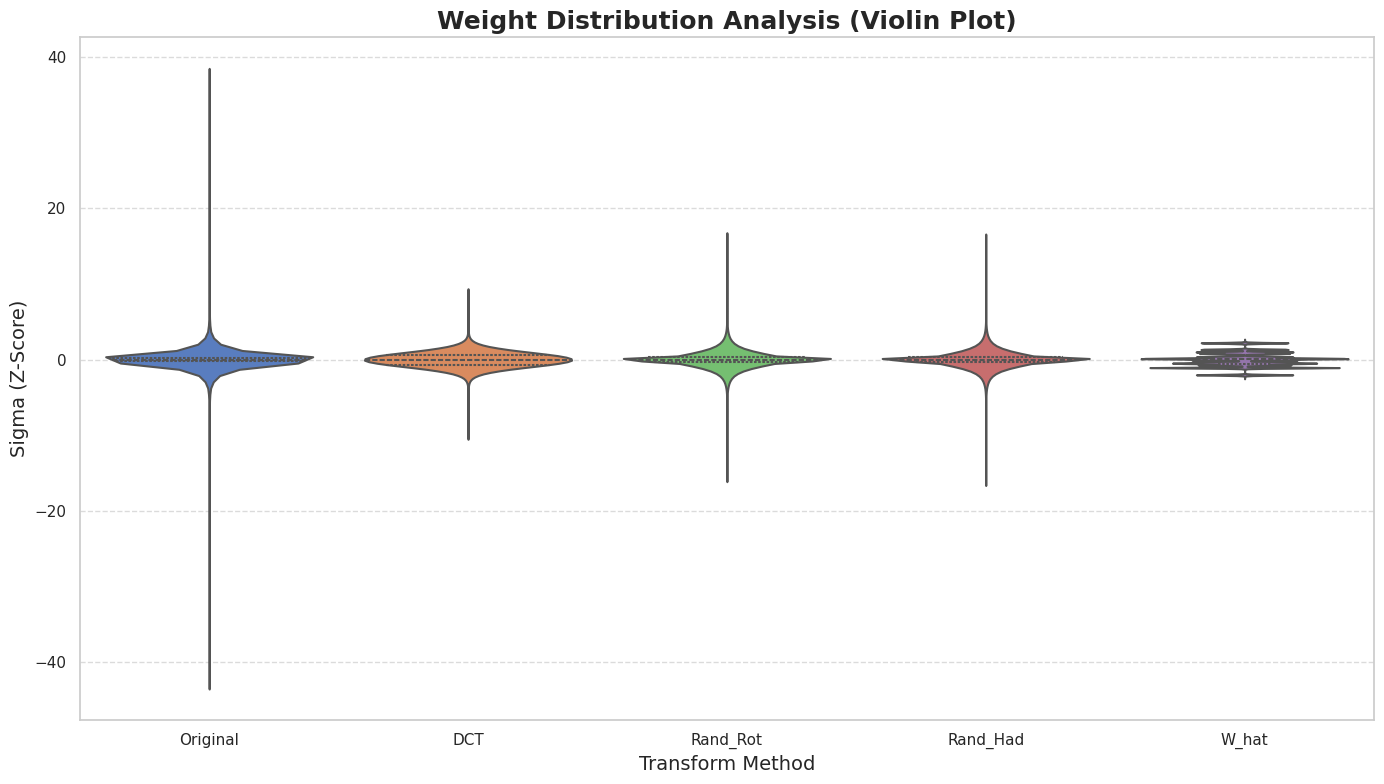

In [12]:
import numpy as np
import pandas as pd  # DataFrame 변환용
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kurtosis
from scipy.fftpack import dctn
from scipy.linalg import hadamard

# -------------------------------------------------------
# 1. 유틸리티 및 데이터 생성 (기존과 동일)
# -------------------------------------------------------
def normalize_zscore(data):
    eps = 1e-8
    return (data - np.mean(data)) / (np.std(data) + eps)

def apply_dct(mat):
    return dctn(mat, type=2, norm='ortho')

def apply_random_rotation(mat):
    dim = mat.shape[0]
    H = np.random.randn(dim, dim)
    Q, _ = np.linalg.qr(H) 
    return Q @ mat

def apply_randomized_hadamard(mat):
    rows, cols = mat.shape
    max_dim = max(rows, cols)
    next_power_of_2 = 2**int(np.ceil(np.log2(max_dim)))
    padded = np.zeros((next_power_of_2, next_power_of_2))
    padded[:rows, :cols] = mat
    signs = np.random.choice([-1, 1], size=(next_power_of_2, 1))
    H = hadamard(next_power_of_2)
    return H @ (padded * signs) / np.sqrt(next_power_of_2)


w_np = to_numpy(W)
w_hat_np = to_numpy(W_hat)

data_dict = {
    "Original": normalize_zscore(w_np.flatten()),
    "Rand_Rot": normalize_zscore(apply_random_rotation(w_np).flatten()),
    "Rand_Had": normalize_zscore(apply_randomized_hadamard(w_np).flatten()),
    "DCT": normalize_zscore(apply_dct(w_np).flatten()),
    "NWC_enc": normalize_zscore(w_hat_np.flatten()),
}

# -------------------------------------------------------
# 2. [핵심] Pandas DataFrame으로 변환
# -------------------------------------------------------
# Seaborn 바이올린 플롯은 Long-form 데이터프레임일 때 가장 예쁘게 그려집니다.
df_list = []
for name, data in data_dict.items():
    # 데이터가 너무 많으면 시각화가 느려질 수 있으므로 샘플링 (옵션)
    # sample_data = np.random.choice(data, 20000, replace=False) if len(data) > 20000 else data
    
    temp_df = pd.DataFrame({"Method": name, "Sigma": data})
    df_list.append(temp_df)

df = pd.concat(df_list, ignore_index=True)

# -------------------------------------------------------
# 3. 시각화 (Violin Plot)
# -------------------------------------------------------

# 통계 출력
# (1) 통계 테이블 출력
print(f"{'Tensor':<10} | {'Kurtosis':<10} | {'Max Sigma':<10} | {'Outlier(>3σ)':<15}")
print("-" * 55)
stats_list = []
for name, data in data_dict.items():
    kurt = kurtosis(data)
    max_sigma = np.max(np.abs(data))
    outlier_pct = np.sum(np.abs(data) > 3) / len(data) * 100
    
    print(f"{name:<10} | {kurt:<10.2f} | {max_sigma:<10.2f} | {outlier_pct:.2f}%")

plt.figure(figsize=(14, 8))

# 스타일 설정
sns.set_theme(style="whitegrid")

# 바이올린 플롯 그리기
# inner="quartile": 내부에 박스 플롯 대신 4분위수(25%, 50%, 75%) 선을 그립니다.
# cut=0: 데이터가 존재하는 범위까지만 그립니다. (Outlier 확인에 좋음)
sns.violinplot(
    data=df, 
    x="Method", 
    y="Sigma", 
    palette="muted", 
    inner="quartile", 
    linewidth=1.5,
    cut=0 
)

plt.title("Weight Distribution Analysis (Violin Plot)", fontsize=18, fontweight='bold')
plt.ylabel("Sigma (Z-Score)", fontsize=14)
plt.xlabel("Transform Method", fontsize=14)

# Y축에 그리드 추가 (가독성)
plt.grid(True, axis='y', linestyle='--', alpha=0.7)

# [옵션] Y축 범위를 제한하여 중심부(Body) 모양을 더 자세히 보고 싶을 때 주석 해제
# plt.ylim(-5, 5) 

plt.tight_layout()
plt.show()